In [ ]:
import pyspark
import pandas as pd
import numpy as np
import librosa as lb
import soundfile as sf
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
import os
import matplotlib.pyplot as plt
import scipy.stats
from tqdm import tqdm

Splitting audio files

In [ ]:
from pydub import AudioSegment
import os
import shutil

# Function to segment audio files into 15-second clips
def segment_audio(input_folder, output_folder):
    genres = os.listdir(input_folder)
    for g in genres:
        genre_path = os.path.join(input_folder, g)
        genre_output_path = os.path.join(output_folder, g)
        if not os.path.exists(genre_output_path):
            os.makedirs(genre_output_path)

        for j, filename in enumerate(os.listdir(genre_path), start=1):
            song_path = os.path.join(genre_path, filename)
            audio = AudioSegment.from_wav(song_path)

            for w in range(0, 2):  # 2 segments of 15 seconds each for 30-second clips
                t1 = 15 * w * 1000
                t2 = 15 * (w + 1) * 1000
                segment = audio[t1:t2]
                segment.export(os.path.join(genre_output_path, f'{g}{j}_{w}.wav'), format="wav")

# Define folders
input_folder = "/content/drive/MyDrive/Genre-prediction/Data/genres_original/"
output_folder = "/content/drive/MyDrive/Genre-prediction/Data/genres_original_split/"

# Call the function to split audio
segment_audio(input_folder, output_folder)

Extracting all the file locations

In [ ]:
root = "/content/drive/MyDrive/Genre-prediction/Data/genres_original_split/"
genres = os.listdir(root)
loc_dict = {}
for i in range(len(genres)):
  loc_dict[genres[i]] = [root + genres[i] + "/" + s for s in os.listdir(root+genres[i])]
for i in range(len(genres)):
  loc_dict[genres[i]] = np.sort(loc_dict[genres[i]])

In [ ]:
!pip install pydub

Preprocessing data to make vectors of sound files

In [ ]:
y, sr = lb.load(loc_dict[genres[0]][0])

In [ ]:
mfcc_feature = lb.feature.mfcc(y=y, sr=sr, n_mfcc=35)
mfcc_feature

array([[-240.63542  , -211.21436  , -193.90889  , ..., -109.999146 ,
         -86.81443  ,  -84.073586 ],
       [  99.64764  ,  101.04283  ,  102.243965 , ...,  150.07935  ,
         138.94867  ,  138.30977  ],
       [  -7.403275 ,   -8.358525 ,    1.9154347, ...,  -50.795135 ,
         -36.536144 ,  -28.136356 ],
       ...,
       [   1.5036576,    1.7557156,   -2.3306231, ...,   -3.9485881,
          -5.122314 ,   -4.100124 ],
       [  -5.0710707,   -3.2813368,   -4.2690735, ...,  -12.276295 ,
          -6.8055   ,   -3.0735126],
       [  12.547274 ,   11.283304 ,    6.903902 , ...,    3.3518233,
          -1.4115528,   -1.3113024]], dtype=float32)

In [ ]:
thres = 0.7
count = [0 for i in range(35)]
for i in range(len(mfcc_feature)):
  temp = 0
  for j in range(len(mfcc_feature)):
    if i!=j:
      a = mfcc_feature[i]
      b = mfcc_feature[j]
      res = cosine_similarity(np.reshape(a,(1,-1)), np.reshape(b,(1,-1)))[0][0]
      if abs(res) > thres:
        temp+=1
  count[i] = temp

print(count)

[4, 9, 3, 8, 0, 5, 8, 7, 4, 4, 3, 4, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [ ]:
y, sr = lb.load('/content/drive/MyDrive/Genre-prediction/Data/genres_original/blues/blues.00023.wav')

In [ ]:
mfcc_feature = lb.feature.mfcc(y=y, sr=sr, n_mfcc=35)
mfcc_feature

array([[-124.20958   , -155.09088   , -241.85445   , ..., -182.60489   ,
        -181.877     , -188.7821    ],
       [ 129.37506   ,  138.43329   ,  131.54944   , ...,  162.08856   ,
         163.08113   ,  168.67728   ],
       [ -36.00989   ,  -40.366325  ,  -29.816128  , ...,  -13.01735   ,
         -12.40883   ,  -12.419767  ],
       ...,
       [  -2.1427677 ,    1.2962606 ,   -0.92716837, ...,   -2.9686048 ,
          -1.3418221 ,   -0.4317072 ],
       [  -3.8935223 ,   -4.2352133 ,   -5.880407  , ...,   -8.965696  ,
          -6.7893467 ,   -5.777566  ],
       [  -6.3549566 ,   -7.7912164 ,   -5.0795574 , ...,   -4.280948  ,
          -7.4512997 ,   -8.880575  ]], dtype=float32)

In [ ]:
thres = 0.7
count = [0 for i in range(35)]
for i in range(len(mfcc_feature)):
  temp = 0
  for j in range(len(mfcc_feature)):
    if i!=j:
      a = mfcc_feature[i]
      b = mfcc_feature[j]
      res = cosine_similarity(np.reshape(a,(1,-1)), np.reshape(b,(1,-1)))[0][0]
      if abs(res) > thres:
        temp+=1
  count[i] = temp

print(count)

[3, 5, 0, 5, 0, 3, 0, 0, 0, 0, 0, 3, 3, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 2, 1, 0, 0]


MelSpectrogram

In [ ]:
y, sr = lb.load(loc_dict[genres[0]][1])

In [ ]:
melspec = lb.feature.melspectrogram(y = y, sr = sr, n_mels = 128, fmax = 8000)
melspec

array([[4.98924196e-01, 1.20295095e+00, 1.26185179e+01, ...,
        6.00200558e+00, 1.99919617e+00, 5.80248070e+00],
       [8.06366801e-01, 9.87913704e+00, 1.79898499e+02, ...,
        1.09908195e+02, 5.72080956e+01, 5.10079689e+01],
       [3.03733945e-01, 1.98640270e+01, 2.31357285e+02, ...,
        5.99522285e+01, 5.01860123e+01, 4.44094620e+01],
       ...,
       [8.01403166e-06, 1.50544583e-04, 1.46468286e-03, ...,
        9.72383935e-03, 5.90245565e-03, 6.12919033e-03],
       [5.04190120e-06, 1.26120969e-04, 1.32422464e-03, ...,
        7.77006708e-03, 6.18789671e-03, 6.04644045e-03],
       [9.90295939e-06, 2.48510245e-04, 1.76255708e-03, ...,
        1.16222864e-02, 8.21589492e-03, 1.01863835e-02]], dtype=float32)

In [ ]:
S = lb.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax = 5000)
S

array([[3.94078374e-01, 4.23937023e-01, 4.15235710e+00, ...,
        9.61630821e-01, 1.30660927e+00, 3.23649049e+00],
       [8.58059943e-01, 6.77472925e+00, 1.01230515e+02, ...,
        6.75100174e+01, 2.57349873e+01, 3.05607471e+01],
       [5.59268594e-01, 1.58297176e+01, 2.81311157e+02, ...,
        1.27839821e+02, 8.96143723e+01, 7.08694687e+01],
       ...,
       [1.79676281e-05, 2.63907388e-03, 1.60653740e-02, ...,
        6.89762412e-03, 1.05206082e-02, 7.77102355e-03],
       [4.21924778e-05, 3.04263667e-03, 2.03671735e-02, ...,
        4.07454595e-02, 4.48654965e-02, 1.98892895e-02],
       [4.08357919e-05, 1.57492713e-03, 1.56572144e-02, ...,
        5.43828495e-02, 4.09034118e-02, 4.21955995e-02]], dtype=float32)

In [ ]:
len(melspec)

128

[Text(0.5, 1.0, 'Mel-frequency spectrogram')]

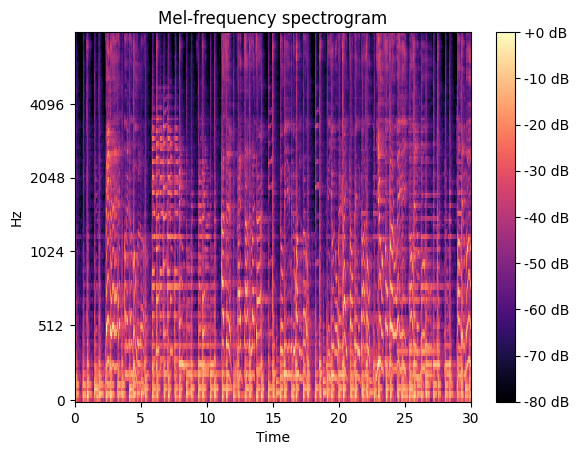

In [ ]:
fig, ax = plt.subplots()
S_dB = lb.power_to_db(melspec,ref=np.max)
img = lb.display.specshow(S_dB, x_axis='time',
                         y_axis='mel', sr=sr,
                         fmax=8000, ax=ax)
fig.colorbar(img, ax=ax, format='%+2.0f dB')
ax.set(title='Mel-frequency spectrogram')

Chroma Constant-Q Chromagram

In [ ]:
y, sr = lb.load(loc_dict[genres[0]][0])

In [ ]:
S_cqt = lb.feature.chroma_cqt(y=y, sr=sr, n_chroma = 12, hop_length = 512, bins_per_octave=24)
S_cqt

array([[1.        , 1.        , 1.        , ..., 0.61256886, 0.77383065,
        0.8186384 ],
       [0.60219955, 0.5224855 , 0.42529967, ..., 0.60614437, 0.74040574,
        0.77996755],
       [0.3892556 , 0.37405348, 0.27689606, ..., 0.60483706, 0.6610252 ,
        0.5229453 ],
       ...,
       [0.658142  , 0.60968024, 0.54131985, ..., 0.9100464 , 0.9664326 ,
        0.96343285],
       [0.5243657 , 0.44830534, 0.3770745 , ..., 0.9958456 , 1.        ,
        1.        ],
       [0.89807296, 0.8776519 , 0.90095115, ..., 1.        , 0.7142356 ,
        0.71614987]], dtype=float32)

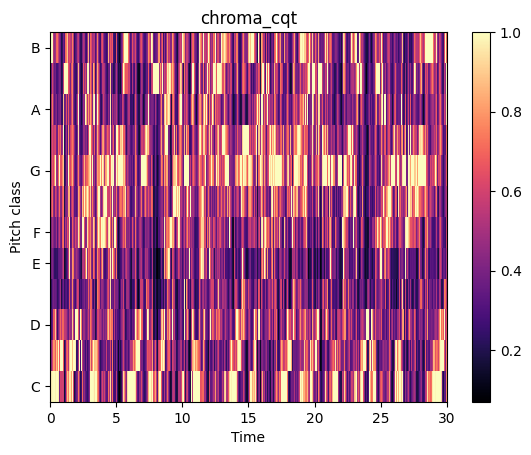

In [ ]:
fig, ax = plt.subplots(nrows=1, sharex=True, sharey=True)
img = lb.display.specshow(S_cqt, y_axis='chroma', x_axis='time', ax=ax)
ax.set(title='chroma_cqt')
fig.colorbar(img, ax=ax)

Chroma Energy Normalised (CENS)

In [ ]:
y, sr = lb.load(loc_dict[genres[0]][0])

In [ ]:
S_cens = lb.feature.chroma_cens(y=y, sr=sr, n_chroma = 12, hop_length = 512, bins_per_octave=24)
S_cens

array([[0.49373648, 0.49289966, 0.49190137, ..., 0.20902856, 0.20683962,
        0.20567192],
       [0.3099472 , 0.31558403, 0.32104653, ..., 0.42398238, 0.41203997,
        0.39935252],
       [0.18268548, 0.19185391, 0.2009652 , ..., 0.39026144, 0.3844905 ,
        0.37809914],
       ...,
       [0.24686824, 0.24644983, 0.24595068, ..., 0.31478095, 0.3194707 ,
        0.32417762],
       [0.24686824, 0.24633507, 0.24542364, ..., 0.27467924, 0.28437713,
        0.29455465],
       [0.43955573, 0.43175292, 0.424182  , ..., 0.3508197 , 0.35551786,
        0.35989803]], dtype=float32)

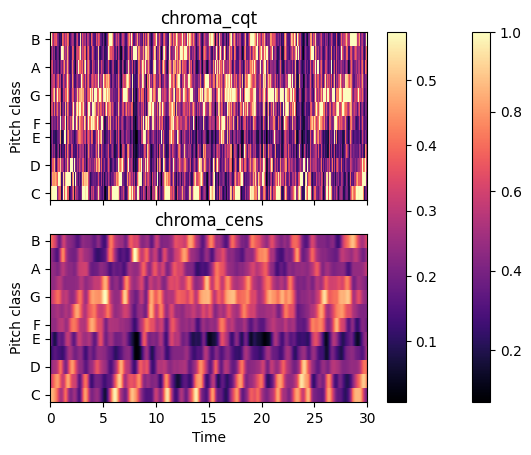

In [ ]:
fig, ax = plt.subplots(nrows=2, sharex=True, sharey=True)
img = lb.display.specshow(S_cqt, y_axis='chroma', x_axis='time', ax=ax[0])
ax[0].set(title='chroma_cqt')
ax[0].label_outer()
fig.colorbar(img, ax=ax)
img = lb.display.specshow(S_cens, y_axis='chroma', x_axis='time', ax=ax[1])
ax[1].set(title='chroma_cens')
fig.colorbar(img, ax=ax)

Spectral Centroid

In [ ]:
y, sr = lb.load(loc_dict[genres[0]][1])

In [ ]:
S_centroid = lb.feature.spectral_centroid(y=y, sr=sr)
S_centroid

array([[ 886.90854909, 1051.83134743, 1125.26706995, ..., 2048.37000305,
        2010.93141731, 1972.07978618]])

In [ ]:
S, phase = lb.magphase(lb.stft(y=y))
lb.feature.spectral_centroid(S=S)

array([[ 886.90854909, 1051.83134743, 1125.26706995, ..., 2048.37000305,
        2010.93141731, 1972.07978618]])

In [ ]:
freqs, times, D = lb.reassigned_spectrogram(y, fill_nan=True)
lb.feature.spectral_centroid(S=np.abs(D), freq=freqs)

array([[ 886.9327317 , 1051.87821299, 1125.28253635, ..., 2048.38326711,
        2010.89825706, 1972.05246176]])

[Text(0.5, 1.0, 'log Power spectrogram')]

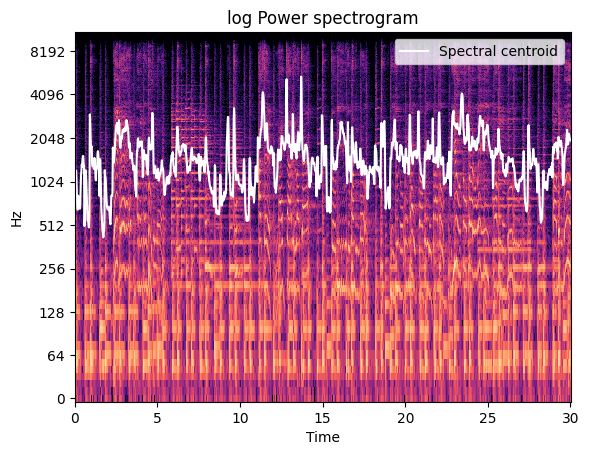

In [ ]:
times = lb.times_like(S_centroid)
fig, ax = plt.subplots()
lb.display.specshow(lb.amplitude_to_db(S, ref=np.max),
                         y_axis='log', x_axis='time', ax=ax)
ax.plot(times, S_centroid.T, label='Spectral centroid', color='w')
ax.legend(loc='upper right')
ax.set(title='log Power spectrogram')

Spectral Bandwidth

In [ ]:
y, sr = lb.load(loc_dict[genres[0]][0])

In [ ]:
S_bandwidth = lb.feature.spectral_bandwidth(y=y, sr=sr)
S_bandwidth

array([[2283.08439586, 2247.35232093, 2308.61530251, ..., 1515.84393596,
        1735.2594234 , 1764.34080935]])

In [ ]:
S, phase = lb.magphase(lb.stft(y=y))
lb.feature.spectral_bandwidth(S=S)

array([[2283.08439586, 2247.35232093, 2308.61530251, ..., 1515.84393596,
        1735.2594234 , 1764.34080935]])

In [ ]:
freqs, times, D = lb.reassigned_spectrogram(y, fill_nan=True)
lb.feature.spectral_bandwidth(S=np.abs(D), freq=freqs)

array([[2283.11191837, 2247.39785146, 2308.66307711, ..., 1515.86016275,
        1735.17746535, 1764.34479761]])

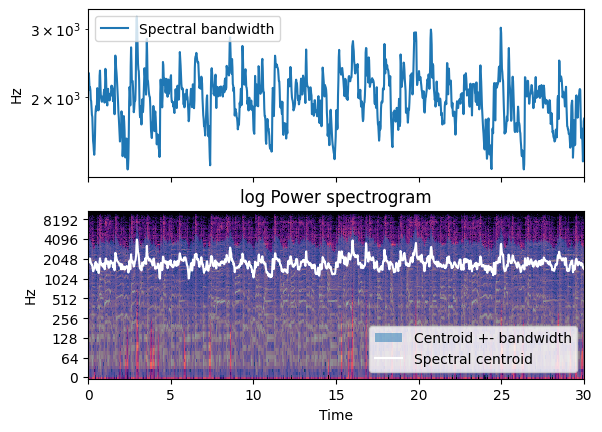

In [ ]:
fig, ax = plt.subplots(nrows=2, sharex=True)
times = lb.times_like(S_bandwidth)
centroid = lb.feature.spectral_centroid(S=S)
ax[0].semilogy(times, S_bandwidth[0], label='Spectral bandwidth')
ax[0].set(ylabel='Hz', xticks=[], xlim=[times.min(), times.max()])
ax[0].legend()
ax[0].label_outer()
lb.display.specshow(lb.amplitude_to_db(S, ref=np.max), y_axis='log', x_axis='time', ax=ax[1])
ax[1].set(title='log Power spectrogram')
ax[1].fill_between(times, np.maximum(0, centroid[0] - S_bandwidth[0]), np.minimum(centroid[0] + S_bandwidth[0], sr/2), alpha=0.5, label='Centroid +- bandwidth')
ax[1].plot(times, centroid[0], label='Spectral centroid', color='w')
ax[1].legend(loc='lower right')

Spectral Flatness

In [ ]:
y, sr = lb.load(loc_dict[genres[0]][0])
S_flatness = lb.feature.spectral_flatness(y=y)
S_flatness

array([[0.0145618 , 0.01049567, 0.00578466, ..., 0.00196063, 0.00379042,
        0.00546285]], dtype=float32)

In [ ]:
S, phase = lb.magphase(lb.stft(y))
lb.feature.spectral_flatness(S=S)

array([[0.0145618 , 0.01049567, 0.00578466, ..., 0.00196063, 0.00379042,
        0.00546285]], dtype=float32)

In [ ]:
S, phase = lb.magphase(lb.stft(y))
S_power = S ** 2
lb.feature.spectral_flatness(S = S_power, power = 1.0)

array([[0.0145618 , 0.01049567, 0.00578466, ..., 0.00196063, 0.00379042,
        0.00546285]], dtype=float32)

Spectral Rolloff

In [ ]:
y, sr = lb.load(loc_dict[genres[0]][0])
lb.feature.spectral_rolloff(y=y, sr=sr)
S_rolloff = lb.feature.spectral_rolloff(y = y, sr = sr, roll_percent=0.9)
S_rolloff_min = lb.feature.spectral_rolloff(y=y, sr = sr, roll_percent = 0.1)

In [ ]:
S, phase = lb.magphase(lb.stft(y))
lb.feature.spectral_rolloff(y = y, sr=sr)
lb.feature.spectral_rolloff(y = y, sr=sr, roll_percent=0.95)

array([[7084.42382812, 7052.12402344, 7041.35742188, ..., 4651.171875  ,
        5351.00097656, 5286.40136719]])

[Text(0.5, 1.0, 'log Power spectrogram')]

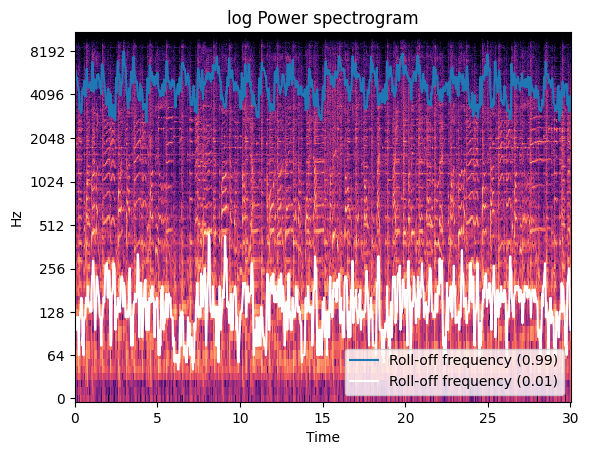

In [ ]:
fig, ax = plt.subplots()
lb.display.specshow(lb.amplitude_to_db(S, ref=np.max),y_axis='log', x_axis='time', ax=ax)
ax.plot(lb.times_like(S_rolloff), S_rolloff[0], label='Roll-off frequency (0.99)')
ax.plot(lb.times_like(S_rolloff), S_rolloff_min[0], color='w',
        label='Roll-off frequency (0.01)')
ax.legend(loc='lower right')
ax.set(title='log Power spectrogram')

RMS

In [ ]:
y, sr = lb.load(loc_dict[genres[0]][0])
lb.feature.rms(y=y)

array([[0.01908039, 0.03683019, 0.0497628 , ..., 0.1405525 , 0.12789187,
        0.11043249]], dtype=float32)

In [ ]:
S, phase = lb.magphase(lb.stft(y))
rms = lb.feature.rms(S=S)

[Text(0.5, 1.0, 'log Power spectrogram')]

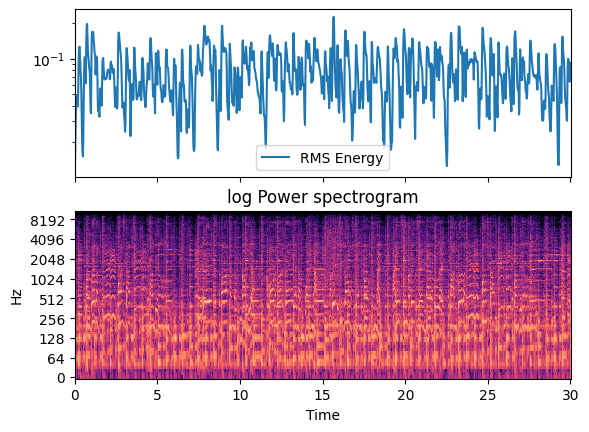

In [ ]:
fig, ax = plt.subplots(nrows=2, sharex=True)
times = lb.times_like(rms)
ax[0].semilogy(times, rms[0], label='RMS Energy')
ax[0].set(xticks=[])
ax[0].legend()
ax[0].label_outer()
lb.display.specshow(lb.amplitude_to_db(S, ref=np.max),
                         y_axis='log', x_axis='time', ax=ax[1])
ax[1].set(title='log Power spectrogram')

Tonnetz

In [ ]:
y, sr = lb.load(loc_dict[genres[0]][0])
y = lb.effects.harmonic(y)
S_tonnetz = lb.feature.tonnetz(y=y, sr = sr)

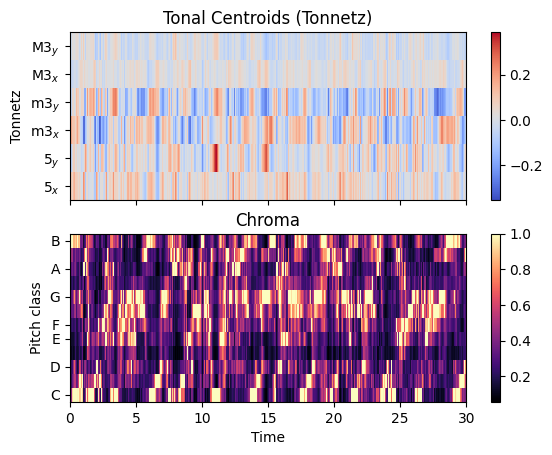

In [ ]:
fig, ax = plt.subplots(nrows=2, sharex=True)
img1 = lb.display.specshow(S_tonnetz,
                                y_axis='tonnetz', x_axis='time', ax=ax[0])
ax[0].set(title='Tonal Centroids (Tonnetz)')
ax[0].label_outer()
img2 = lb.display.specshow(lb.feature.chroma_cqt(y=y, sr=sr),
                                y_axis='chroma', x_axis='time', ax=ax[1])
ax[1].set(title='Chroma')
fig.colorbar(img1, ax=[ax[0]])
fig.colorbar(img2, ax=[ax[1]])

Tempo

In [ ]:
y, sr = lb.load(loc_dict[genres[0]][0])
onset_env = lb.onset.onset_strength(y=y, sr=sr)
tempo = lb.feature.tempo(onset_envelope=onset_env, sr=sr)

In [ ]:
prior = scipy.stats.uniform(30, 300)  # uniform over 30-300 BPM
utempo = lb.feature.tempo(onset_envelope=onset_env, sr=sr, prior=prior)
utempo

array([123.046875])

In [ ]:
dtempo = lb.feature.tempo(onset_envelope=onset_env, sr=sr,aggregate=None)
dtempo

array([129.19921875, 129.19921875, 129.19921875, ..., 123.046875  ,
       123.046875  , 123.046875  ])

In [ ]:
prior_lognorm = scipy.stats.lognorm(loc=np.log(120), scale=120, s=1)
dtempo_lognorm = lb.feature.tempo(onset_envelope=onset_env, sr=sr,
                                       aggregate=None,
                                       prior=prior_lognorm)
dtempo_lognorm

array([63.02400915, 63.02400915, 63.02400915, ..., 61.5234375 ,
       61.5234375 , 61.5234375 ])

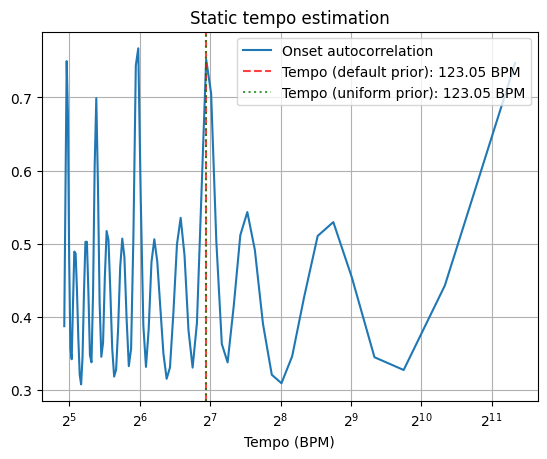

In [ ]:
tempo = tempo.item()
utempo = utempo.item()
# Compute 2-second windowed autocorrelation
hop_length = 512
ac = lb.autocorrelate(onset_env, max_size=2 * sr // hop_length)
freqs = lb.tempo_frequencies(len(ac), sr=sr,
                                  hop_length=hop_length)
# Plot on a BPM axis.  We skip the first (0-lag) bin.
fig, ax = plt.subplots()
ax.semilogx(freqs[1:], lb.util.normalize(ac)[1:],
             label='Onset autocorrelation', base=2)
ax.axvline(tempo, 0, 1, alpha=0.75, linestyle='--', color='r',
            label='Tempo (default prior): {:.2f} BPM'.format(tempo))
ax.axvline(utempo, 0, 1, alpha=0.75, linestyle=':', color='g',
            label='Tempo (uniform prior): {:.2f} BPM'.format(utempo))
ax.set(xlabel='Tempo (BPM)', title='Static tempo estimation')
ax.grid(True)
ax.legend()

/usr/local/lib/python3.11/dist-packages/IPython/core/events.py:89: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


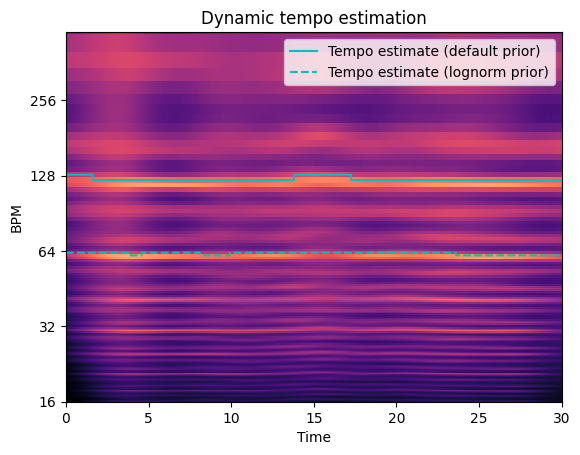

In [ ]:
fig, ax = plt.subplots()
tg = lb.feature.tempogram(onset_envelope=onset_env, sr=sr,
                               hop_length=hop_length)
lb.display.specshow(tg, x_axis='time', y_axis='tempo', cmap='magma', ax=ax)
ax.plot(lb.times_like(dtempo), dtempo,
         color='c', linewidth=1.5, label='Tempo estimate (default prior)')
ax.plot(lb.times_like(dtempo_lognorm), dtempo_lognorm,
         color='c', linewidth=1.5, linestyle='--',
         label='Tempo estimate (lognorm prior)')
ax.set(title='Dynamic tempo estimation')
ax.legend()

Chroma Short form fourier transform

In [ ]:
y, sr = lb.load(loc_dict[genres[0]][0])
lb.feature.chroma_stft(y=y, sr=sr)

array([[0.33112544, 0.23492372, 0.8714165 , ..., 0.15691066, 0.87786204,
        1.        ],
       [0.39392966, 0.29400367, 0.6882651 , ..., 0.13222207, 0.68507576,
        0.7281689 ],
       [0.42932406, 0.41955495, 0.51602733, ..., 0.25044858, 0.56496435,
        0.40339905],
       ...,
       [1.        , 1.        , 1.        , ..., 0.2619948 , 0.95514834,
        0.86573505],
       [0.42033246, 0.36797962, 0.6217583 , ..., 1.        , 1.        ,
        0.9858056 ],
       [0.30348283, 0.19700052, 0.64925486, ..., 0.6287608 , 0.71722466,
        0.81626564]], dtype=float32)

In [ ]:
S = np.abs(lb.stft(y))
chroma = lb.feature.chroma_stft(S=S, sr=sr)

In [ ]:
S = np.abs(lb.stft(y))**2
chroma = lb.feature.chroma_stft(S=S, sr=sr)

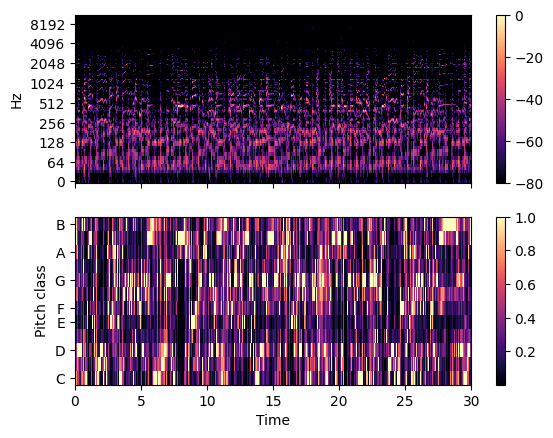

In [ ]:
fig, ax = plt.subplots(nrows=2, sharex=True)
img = lb.display.specshow(lb.amplitude_to_db(S, ref=np.max),
                               y_axis='log', x_axis='time', ax=ax[0])
fig.colorbar(img, ax=[ax[0]])
ax[0].label_outer()
img = lb.display.specshow(chroma, y_axis='chroma', x_axis='time', ax=ax[1])
fig.colorbar(img, ax=[ax[1]])

In [ ]:
!pip install pydub

In [ ]:
root = "/content/drive/MyDrive/Genre-prediction/Data/genres_original_split/"
genres = os.listdir(root)
loc_dict = {}
for i in range(len(genres)):
  loc_dict[genres[i]] = [root + genres[i] + "/" + s for s in os.listdir(root+genres[i])]
for i in range(len(genres)):
  loc_dict[genres[i]] = np.sort(loc_dict[genres[i]])

In [ ]:
y, sr = lb.load(loc_dict[genres[0]][0])

#melspectrogram
S_mel = lb.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax = 5000)
fig, ax = plt.subplots()
S_meldB = lb.power_to_db(S_mel, ref=np.max)
img = lb.display.specshow(S_meldB, x_axis='time',
                         y_axis='mel', sr=sr,
                         fmax=8000, ax=ax)
fig.colorbar(img, ax=ax, format='%+2.0f dB')
ax.set(title='Mel-frequency spectrogram')

#CQT
S_cqt = lb.feature.chroma_cqt(y=y, sr=sr, n_chroma = 12, hop_length = 512, bins_per_octave=24)
fig, ax = plt.subplots(nrows=1, sharex=True, sharey=True)
img = lb.display.specshow(S_cqt, y_axis='chroma', x_axis='time', ax=ax)
ax.set(title='chroma_cqt')
fig.colorbar(img, ax=ax)

#Cens
S_cens = lb.feature.chroma_cens(y=y, sr=sr, n_chroma = 12, hop_length = 512, bins_per_octave=24)
fig, ax = plt.subplots(nrows=2, sharex=True, sharey=True)
img = lb.display.specshow(S_cqt, y_axis='chroma', x_axis='time', ax=ax[0])
ax[0].set(title='chroma_cqt')
ax[0].label_outer()
fig.colorbar(img, ax=ax)
img = lb.display.specshow(S_cens, y_axis='chroma', x_axis='time', ax=ax[1])
ax[1].set(title='chroma_cens')
fig.colorbar(img, ax=ax)

#spectral centroid
S_centroid = lb.feature.spectral_centroid(y=y, sr=sr)
S_cent, phase_cent = lb.magphase(lb.stft(y=y))
times_cent = lb.times_like(S_centroid)
fig, ax = plt.subplots()
lb.display.specshow(lb.amplitude_to_db(S_cent, ref=np.max),
                         y_axis='log', x_axis='time', ax=ax)
ax.plot(times_cent, S_centroid.T, label='Spectral centroid', color='w')
ax.legend(loc='upper right')
ax.set(title='log Power spectrogram')

#spectral bandwidth
S_bandwidth = lb.feature.spectral_bandwidth(y=y, sr=sr)
S_band, phase_band = lb.magphase(lb.stft(y=y))
fig, ax = plt.subplots(nrows=2, sharex=True)
times_band = lb.times_like(S_bandwidth)
centroid = lb.feature.spectral_centroid(S=S_band)
ax[0].semilogy(times_band, S_bandwidth[0], label='Spectral bandwidth')
ax[0].set(ylabel='Hz', xticks=[], xlim=[times_band.min(), times_band.max()])
ax[0].legend()
ax[0].label_outer()
lb.display.specshow(lb.amplitude_to_db(S_band, ref=np.max), y_axis='log', x_axis='time', ax=ax[1])
ax[1].set(title='log Power spectrogram')
ax[1].fill_between(times_band, np.maximum(0, centroid[0] - S_bandwidth[0]), np.minimum(centroid[0] + S_bandwidth[0], sr/2), alpha=0.5, label='Centroid +- bandwidth')
ax[1].plot(times_band, centroid[0], label='Spectral centroid', color='w')
ax[1].legend(loc='lower right')

#Rolloff
S_rolloff = lb.feature.spectral_rolloff(y = y, sr = sr, roll_percent=0.9)
S_rolloff_min = lb.feature.spectral_rolloff(y=y, sr = sr, roll_percent = 0.1)
S_roll, phase_rms = lb.magphase(lb.stft(y))
fig, ax = plt.subplots()
lb.display.specshow(lb.amplitude_to_db(S_roll, ref=np.max),y_axis='log', x_axis='time', ax=ax)
ax.plot(lb.times_like(S_rolloff), S_rolloff[0], label='Roll-off frequency (0.99)')
ax.plot(lb.times_like(S_rolloff), S_rolloff_min[0], color='w',
        label='Roll-off frequency (0.01)')
ax.legend(loc='lower right')
ax.set(title='log Power spectrogram')

#rms
S_rms, phase_rms = lb.magphase(lb.stft(y))
rms = lb.feature.rms(S=S_rms)
fig, ax = plt.subplots(nrows=2, sharex=True)
times_rms = lb.times_like(rms)
ax[0].semilogy(times_rms, rms[0], label='RMS Energy')
ax[0].set(xticks=[])
ax[0].legend()
ax[0].label_outer()
lb.display.specshow(lb.amplitude_to_db(S_rms, ref=np.max),
                         y_axis='log', x_axis='time', ax=ax[1])
ax[1].set(title='log Power spectrogram')

#tonnetz
y_tonnetz = lb.effects.harmonic(y)
S_tonnetz = lb.feature.tonnetz(y=y_tonnetz, sr = sr)
fig, ax = plt.subplots(nrows=2, sharex=True)
img1 = lb.display.specshow(S_tonnetz,
                                y_axis='tonnetz', x_axis='time', ax=ax[0])
ax[0].set(title='Tonal Centroids (Tonnetz)')
ax[0].label_outer()
img2 = lb.display.specshow(lb.feature.chroma_cqt(y=y_tonnetz, sr=sr),
                                y_axis='chroma', x_axis='time', ax=ax[1])
ax[1].set(title='Chroma')
fig.colorbar(img1, ax=[ax[0]])
fig.colorbar(img2, ax=[ax[1]])

#chroma stft
S_stft = np.abs(lb.stft(y))**2
chroma_stft = lb.feature.chroma_stft(S=S_stft, sr=sr)
fig, ax = plt.subplots(nrows=2, sharex=True)
img = lb.display.specshow(lb.amplitude_to_db(S_stft, ref=np.max),
                               y_axis='log', x_axis='time', ax=ax[0])
fig.colorbar(img, ax=[ax[0]])
ax[0].label_outer()
img = lb.display.specshow(chroma_stft, y_axis='chroma', x_axis='time', ax=ax[1])
fig.colorbar(img, ax=[ax[1]])

In [ ]:
def plot_features(y, sr, genre):
    fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(15, 20))
    fig.suptitle(f'Feature Visualizations for {genre}', fontsize=16)

    S_mel = lb.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=5000)
    lb.display.specshow(lb.power_to_db(S_mel, ref=np.max), ax=axes[0, 0], y_axis='mel', x_axis='time')
    axes[0, 0].set_title('Mel-frequency spectrogram')

    S_cqt = lb.feature.chroma_cqt(y=y, sr=sr)
    lb.display.specshow(S_cqt, ax=axes[0, 1], y_axis='chroma', x_axis='time')
    axes[0, 1].set_title('Chroma CQT')

    S_cens = lb.feature.chroma_cens(y=y, sr=sr)
    lb.display.specshow(S_cens, ax=axes[1, 0], y_axis='chroma', x_axis='time')
    axes[1, 0].set_title('Chroma CENS')
    S_centroid = lb.feature.spectral_centroid(y=y, sr=sr)
    axes[1, 1].plot(lb.times_like(S_centroid), S_centroid[0])
    axes[1, 1].set_title('Spectral Centroid')

    S_bandwidth = lb.feature.spectral_bandwidth(y=y, sr=sr)
    axes[2, 0].plot(lb.times_like(S_bandwidth), S_bandwidth[0])
    axes[2, 0].set_title('Spectral Bandwidth')

    S_rolloff = lb.feature.spectral_rolloff(y=y, sr=sr)
    axes[2, 1].plot(lb.times_like(S_rolloff), S_rolloff[0])
    axes[2, 1].set_title('Spectral Rolloff')

    rms = lb.feature.rms(y=y)
    axes[3, 0].plot(lb.times_like(rms), rms[0])
    axes[3, 0].set_title('RMS Energy')

    S_tonnetz = lb.feature.tonnetz(y=lb.effects.harmonic(y), sr=sr)
    lb.display.specshow(S_tonnetz, ax=axes[3, 1], y_axis='tonnetz', x_axis='time')
    axes[3, 1].set_title('Tonnetz')

    chroma_stft = lb.feature.chroma_stft(y=y, sr=sr)
    lb.display.specshow(chroma_stft, ax=axes[4, 0], y_axis='chroma', x_axis='time')
    axes[4, 0].set_title('Chroma STFT')

    plt.tight_layout()
    plt.savefig("/content/drive/MyDrive/Genre-prediction/Data/feature_graphs/"+genre+".png", dpi = 800)
    plt.close()


for genre, song_locations in loc_dict.items():
    y, sr = lb.load(song_locations[0])
    plot_features(y, sr, genre)

In [ ]:
import librosa as lb
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import os

output_dir = "/content/drive/MyDrive/Genre-prediction/Data/feature_graphs/"
os.makedirs(output_dir, exist_ok=True)

def plot_feature_across_genres(feature_name, loc_dict):
    plt.figure(figsize=(15, 10), facecolor='white')
    total_genres = len(loc_dict)
    for i, (genre, song_locations) in tqdm(enumerate(loc_dict.items())):
        y, sr = lb.load(song_locations[0])
        plt.subplot((total_genres + 1) // 2, 2, i + 1)
        plt.title(f'{genre}')

        if feature_name == 'melspectrogramFeature':
            feature = lb.feature.melspectrogram(y=y, sr=sr)
            lb.display.specshow(lb.power_to_db(feature, ref=np.max))
        elif feature_name == 'chromaCqt':
            feature = lb.feature.chroma_cqt(y=y, sr=sr)
            lb.display.specshow(feature)
        elif feature_name == 'chromaCens':
            feature = lb.feature.chroma_cens(y=y, sr=sr)
            lb.display.specshow(feature)
        elif feature_name == 'chromaStft':
            feature = lb.feature.chroma_stft(y=y, sr=sr)
            lb.display.specshow(feature)
        elif feature_name == 'spectralCentroid':
            feature = lb.feature.spectral_centroid(y=y, sr=sr)[0]
            plt.ylim(0,8000)
            plt.plot(lb.times_like(feature), feature)
        elif feature_name == 'spectralBandwidth':
            feature = lb.feature.spectral_bandwidth(y=y, sr=sr)[0]
            plt.ylim(0,4000)
            plt.plot(lb.times_like(feature), feature)
        elif feature_name == 'spectralRolloff':
            feature = lb.feature.spectral_rolloff(y=y, sr=sr)[0]
            plt.ylim(0,10000)
            plt.plot(lb.times_like(feature), feature)
        elif feature_name == 'rms':
            feature = lb.feature.rms(y=y)[0]
            plt.ylim(0,0.4)
            plt.plot(lb.times_like(feature), feature)
        elif feature_name == 'tonnetz':
            feature = lb.feature.tonnetz(y=lb.effects.harmonic(y), sr=sr)
            lb.display.specshow(feature)
        else:
            continue

    plt.suptitle(f'{feature_name} across Genres')
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f'{feature_name}.png'))
    plt.close()

features = [
    'melspectrogramFeature', 'chromaCqt', 'chromaCens', 'chromaStft',
    'spectralCentroid', 'spectralBandwidth', 'spectralRolloff',
    'rms', 'tonnetz'
]

for feature in features:
    plot_feature_across_genres(feature, loc_dict)

# Generating dataframe for data processing

In [ ]:
# SR = 44100  # Sample rate
# FIXED_TIME_FRAMES = 100  # Fixed number of frames
# HOP_LENGTH = 512  # Ensures each frame represents 30 seconds
# N_FFT = 64  # FFT window size

# def mfccFeature(y, sr=SR):
#     return lb.feature.mfcc(y=y, sr=sr, n_mfcc=35, n_fft=N_FFT, hop_length=HOP_LENGTH)

# def melspectrogramFeature(y, sr=SR):
#     return lb.feature.melspectrogram(y=y, sr=sr, n_mels=8, fmax=16000, hop_length=HOP_LENGTH)

# def chromaCqt(y, sr=SR):
#     return lb.feature.chroma_cqt(y=y, sr=sr, n_chroma=12, hop_length=HOP_LENGTH, bins_per_octave=24)

# def chromaCens(y, sr=SR):
#     return lb.feature.chroma_cens(y=y, sr=sr, n_chroma=12, hop_length=HOP_LENGTH, bins_per_octave=24)

# def chromaStft(y, sr=SR):
#     return lb.feature.chroma_stft(y=y, sr=sr, hop_length=HOP_LENGTH)

# def spectralCentroid(y, sr=SR):
#     return lb.feature.spectral_centroid(y=y, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH)

# def spectralBandwidth(y, sr=SR):
#     return lb.feature.spectral_bandwidth(y=y, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH)

# def spectralFlatness(y, sr=SR):
#     return lb.feature.spectral_flatness(y=y, hop_length=HOP_LENGTH)

# def spectralRolloff(y, sr=SR):
#     return lb.feature.spectral_rolloff(y=y, sr=sr, roll_percent=0.85, n_fft=N_FFT, hop_length=HOP_LENGTH)

# def rmsFeature(y):
#     return lb.feature.rms(y=y, hop_length=HOP_LENGTH)

# def tonnetzFeature(y, sr=SR):
#     return lb.feature.tonnetz(y=y, sr=sr)

# def tempoFeature(y, sr=SR):
#     prior = scipy.stats.lognorm(s=1.0, scale=120)
#     onset_env = lb.onset.onset_strength(y=y, sr=sr, hop_length=HOP_LENGTH)
#     return lb.feature.tempo(onset_envelope=onset_env, sr=sr, prior=prior)

# def zcr(y):
#     return lb.feature.zero_crossing_rate(y, hop_length=HOP_LENGTH)

In [133]:
n_mfccs = 20
n_mels = 8
n_chroma = 12

def mfccFeature(y, sr):
    mfcc_feature = lb.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfccs)
    mfcc_stats = []
    for mfcc in mfcc_feature:
      mfcc_stats.append(np.mean(mfcc))
      mfcc_stats.append(np.var(mfcc))
    return mfcc_stats

def melspectrogramFeature(y, sr):
    fmax = min(8000, sr / 2)
    melspec = lb.feature.melspectrogram(y=y, sr=sr*10, n_mels=n_mels, fmax=100000, n_fft=128)
    melspec_stats = []
    for mels in melspec:
      melspec_stats.append(np.mean(mels))
      melspec_stats.append(np.var(mels))
    return melspec_stats

def chromaCqt(y, sr):
    cqt = lb.feature.chroma_cqt(y=y, sr=sr, n_chroma=n_chroma, hop_length=256, bins_per_octave=24)
    cqtStats = []
    for cqtarr in cqt:
      cqtStats.append(np.mean(cqtarr))
      cqtStats.append(np.var(cqtarr))
    return cqtStats

def chromaCens(y, sr):
    cens = lb.feature.chroma_cens(y=y, sr=sr, n_chroma=n_chroma, hop_length=256, bins_per_octave=24)
    censStats = []
    for censarr in cens:
      censStats.append(np.mean(censarr))
      censStats.append(np.var(censarr))
    return censStats

def chromaStft(y, sr):
    stft = lb.feature.chroma_stft(y=y, sr=sr, n_fft=128, n_chroma=n_chroma)
    stftStats = []
    for stftarr in stft:
      stftStats.append(np.mean(stftarr))
      stftStats.append(np.var(stftarr))
    return stftStats

def spectralCentroid(y, sr):
    specCentroid = lb.feature.spectral_centroid(y=y, sr=sr, n_fft=128)
    return [np.mean(specCentroid[0]),np.var(specCentroid[0])]

def spectralBandwidth(y, sr):
    specBandwidth = lb.feature.spectral_bandwidth(y=y, sr=sr, n_fft=128)
    return [np.mean(specBandwidth[0]),np.var(specBandwidth[0])]

def spectralFlatness(y, sr):
    specflatness = lb.feature.spectral_flatness(y=y, n_fft=128)
    return [np.mean(specflatness[0]), np.var(specflatness[0])]

def spectralRolloff(y, sr):
    specRolloff = lb.feature.spectral_rolloff(y=y, sr=sr, roll_percent=0.85, n_fft=128, hop_length=256)
    return [np.mean(specRolloff[0]),np.var(specRolloff[0])]

def rmsFeature(y):
    rms = lb.feature.rms(y=y)
    return [np.mean(rms[0]),np.var(rms[0])]

def tonnetzFeature(y, sr):
    tonnetz = lb.feature.tonnetz(y=y, sr=sr)
    tonnetzStats = []
    for tonnetzarr in tonnetz:
      tonnetzStats.append(np.mean(tonnetzarr))
      tonnetzStats.append(np.var(tonnetzarr))
    return tonnetzStats

def tempoFeature(y, sr):
    prior = scipy.stats.lognorm(s=1.0, scale=120)
    onset_env = lb.onset.onset_strength(y=y, sr=sr)
    tempo = lb.feature.tempo(onset_envelope=onset_env, sr=sr, prior=prior)
    return tempo[0]

def zcr(y):
    zcr = lb.feature.zero_crossing_rate(y)
    return [np.mean(zcr[0]),np.var(zcr[0])]

def getHarmonic(y):
    harm = lb.effects.harmonic(y)
    return [np.mean(harm), np.var(harm)]

def getPercussion(y):
    perc = lb.effects.percussive(y, margin=3.0)
    return [np.mean(perc),np.var(perc)]

def tempogramFeature(y):
    tempogram = lb.effects.tempogram(y, sr)
    return [np.mean(tempogram), np.var(tempogram)]

In [141]:
mfccColumn = []
for i in range(n_mfccs):
  mfccColumn.append("mfccFeatureMean_"+str(i+1))
  mfccColumn.append("mfccFeatureVar_"+str(i+1))

melColumn = []
for i in range(n_mels):
  melColumn.append("melspectrogramMean_"+str(i+1))
  melColumn.append("melspectrogramVar_"+str(i+1))

chromacqtColumn = []
for i in range(n_chroma):
  chromacqtColumn.append("chromaCQTMean_"+str(i+1))
  chromacqtColumn.append("chromaCQTVar_"+str(i+1))


chromaCENSColumn = []
for i in range(n_chroma):
  chromaCENSColumn.append("chromaCENSMean_"+str(i+1))
  chromaCENSColumn.append("chromaCENSVar_"+str(i+1))


chromastftColumn = []
for i in range(n_chroma):
  chromastftColumn.append("chromaSTFTMean_"+str(i+1))
  chromastftColumn.append("chromaSTFTVar_"+str(i+1))

tonnetzColumn = []
for i in range(6):
  tonnetzColumn.append("tonnetzMean_"+str(i+1))
  tonnetzColumn.append("tonnetzVar_"+str(i+1))

cols = ["location", "genre"] +  mfccColumn + melColumn + chromacqtColumn + chromaCENSColumn + chromastftColumn + ["spectralCentroidMean", "spectralCentroidVar", "spectralBandwidthMean", "spectralBandwidthVar", "spectralFlatnessMean", "spectralFlatnessVar", "spectralRolloffMean", "spectralRolloffVar", "rmsMean", "rmsVar"]+ tonnetzColumn + ["tempoValue", "zcrMean", "zcrVar", "harmonicMean", "HarmonicVar"]
df = pd.DataFrame(columns = cols)
df

,location,genre,mfccFeatureMean_1,mfccFeatureVar_1,mfccFeatureMean_2,mfccFeatureVar_2,mfccFeatureMean_3,mfccFeatureVar_3,mfccFeatureMean_4,mfccFeatureVar_4,...,tonnetzVar_4,tonnetzMean_5,tonnetzVar_5,tonnetzMean_6,tonnetzVar_6,tempoValue,zcrMean,zcrVar,harmonicMean,HarmonicVar


In [142]:
for i in genres:
  for j in tqdm(loc_dict[i]):

    # extracting features
    y, sr = lb.load(j)
    mfccValues = mfccFeature(y, sr)
    melspecValues = melspectrogramFeature(y, sr)
    cqtValues = chromaCqt(y, sr)
    censValues = chromaCens(y, sr)
    stftValues = chromaStft(y, sr)
    specCentValue = spectralCentroid(y, sr)
    specBandValue = spectralBandwidth(y, sr)
    specFlatValue = spectralFlatness(y, sr)
    specRollValue = spectralRolloff(y, sr)
    rmsValue = rmsFeature(y)
    tonnetzValues = tonnetzFeature(y, sr)
    tempoValue = tempoFeature(y, sr)
    zcrValues = zcr(y)
    harmonicValues = getHarmonic(y)
    df.loc[len(df)] = [j, i] + mfccValues + melspecValues + cqtValues + censValues + stftValues + specCentValue + specBandValue + specFlatValue + specRollValue + rmsValue + tonnetzValues + [tempoValue] + zcrValues + harmonicValues

    # except FileNotFoundError:
    #     print(f"Warning: File not found - {j}")
    #     continue
    # except lb.util.exceptions.ParameterError:
    #     print(f"Warning: Format not recognized or file corrupted - {j}")
    #     continue
    # except Exception as e:
    #     print(f"Warning: An error occurred with file {j} - {str(e)}")
    #     continue

100%|██████████| 200/200 [06:08<00:00,  1.84s/it]


In [143]:
df.to_pickle("/content/drive/MyDrive/Genre-prediction/Data/dataframe_final.pkl")

In [1]:
import pyspark
import pandas as pd
import numpy as np
import librosa as lb
import soundfile as sf
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
import os
import matplotlib.pyplot as plt
import scipy.stats
from tqdm import tqdm

Extracting all the file locations

In [2]:
root = "Data/genres_original/"
genres = os.listdir(root)
loc_dict = {}
for i in range(len(genres)):
  loc_dict[genres[i]] = [root + genres[i] + "/" + s for s in os.listdir(root+genres[i])]
for i in range(len(genres)):
  loc_dict[genres[i]] = np.sort(loc_dict[genres[i]])

In [3]:
df = pd.read_pickle("dataframe_final.pkl")

In [4]:
df.columns

Index(['location', 'genre', 'mfccFeatureMean_1', 'mfccFeatureVar_1',
       'mfccFeatureMean_2', 'mfccFeatureVar_2', 'mfccFeatureMean_3',
       'mfccFeatureVar_3', 'mfccFeatureMean_4', 'mfccFeatureVar_4',
       ...
       'tonnetzVar_4', 'tonnetzMean_5', 'tonnetzVar_5', 'tonnetzMean_6',
       'tonnetzVar_6', 'tempoValue', 'zcrMean', 'zcrVar', 'harmonicMean',
       'HarmonicVar'],
      dtype='object', length=157)

In [5]:
x = df[df.columns[2:]]
y_mapping = {}
for i in range(len(genres)):
  y_mapping[genres[i]] = i

df['genre_mapping'] = df['genre'].map(y_mapping)

C:\Users\Manav\AppData\Local\Temp\ipykernel_19892\2375555959.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['genre_mapping'] = df['genre'].map(y_mapping)


In [6]:
y = df['genre_mapping']

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
import xgboost as xgb
import lightgbm as lgb

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train shape: {x_train.shape}, Test shape: {x_test.shape}")

Train shape: (1598, 155), Test shape: (400, 155)


In [12]:
lgb_model = lgb.LGBMClassifier(objective = 'multiclass',random_state=42, verbosity=-1)
lgb_model.fit(x_train, y_train)
y_pred_lgb = lgb_model.predict(x_test)

print("LGBoost Classifier")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lgb):.4f}")
print(classification_report(y_test, y_pred_lgb))

LGBoost Classifier
Accuracy: 0.8675
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        40
           1       0.97      0.93      0.95        40
           2       0.82      0.80      0.81        40
           3       0.84      0.78      0.81        40
           4       0.87      0.82      0.85        40
           5       0.88      0.90      0.89        40
           6       0.90      0.88      0.89        40
           7       0.82      1.00      0.90        40
           8       0.90      0.95      0.93        40
           9       0.76      0.70      0.73        40

    accuracy                           0.87       400
   macro avg       0.87      0.87      0.87       400
weighted avg       0.87      0.87      0.87       400



In [13]:
xgb_model = xgb.XGBClassifier(objective='multi:softmax', num_class=len(np.unique(y)), random_state=42)
xgb_model.fit(x_train, y_train)
y_pred_xgb = xgb_model.predict(x_test)

print("XGBoost Classifier")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(classification_report(y_test, y_pred_xgb))

XGBoost Classifier
Accuracy: 0.8375
              precision    recall  f1-score   support

           0       0.86      0.90      0.88        40
           1       0.95      0.88      0.91        40
           2       0.79      0.75      0.77        40
           3       0.77      0.82      0.80        40
           4       0.88      0.88      0.88        40
           5       0.83      0.85      0.84        40
           6       0.85      0.88      0.86        40
           7       0.85      0.97      0.91        40
           8       0.87      0.85      0.86        40
           9       0.73      0.60      0.66        40

    accuracy                           0.84       400
   macro avg       0.84      0.84      0.84       400
weighted avg       0.84      0.84      0.84       400



In [14]:
gb_model = GradientBoostingClassifier(n_estimators=200, random_state=42)
gb_model.fit(x_train, y_train)
y_pred_gb = gb_model.predict(x_test)

print("Random Forest Classifier")
print(f"Accuracy: {accuracy_score(y_test, y_pred_gb):.4f}")
print(classification_report(y_test, y_pred_gb))

Random Forest Classifier
Accuracy: 0.8525
              precision    recall  f1-score   support

           0       0.88      0.88      0.88        40
           1       0.97      0.85      0.91        40
           2       0.84      0.90      0.87        40
           3       0.81      0.75      0.78        40
           4       0.84      0.80      0.82        40
           5       0.90      0.90      0.90        40
           6       0.85      0.85      0.85        40
           7       0.89      0.97      0.93        40
           8       0.81      0.85      0.83        40
           9       0.76      0.78      0.77        40

    accuracy                           0.85       400
   macro avg       0.85      0.85      0.85       400
weighted avg       0.85      0.85      0.85       400



In [15]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(x_train, y_train)
y_pred_rf = rf_model.predict(x_test)

print("Random Forest Classifier")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf))

Random Forest Classifier
Accuracy: 0.8200
              precision    recall  f1-score   support

           0       0.83      0.88      0.85        40
           1       0.90      0.90      0.90        40
           2       0.82      0.70      0.76        40
           3       0.73      0.68      0.70        40
           4       0.85      0.82      0.84        40
           5       0.88      0.90      0.89        40
           6       0.79      0.93      0.85        40
           7       0.81      0.88      0.84        40
           8       0.83      0.88      0.85        40
           9       0.74      0.65      0.69        40

    accuracy                           0.82       400
   macro avg       0.82      0.82      0.82       400
weighted avg       0.82      0.82      0.82       400



In [16]:
# Train SVM model
svm_model = SVC(kernel='rbf', C = 20)
svm_model.fit(x_train, y_train)

# Evaluate
y_pred = svm_model.predict(x_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

Accuracy: 0.3675
              precision    recall  f1-score   support

           0       0.25      0.40      0.31        40
           1       0.70      0.82      0.76        40
           2       0.11      0.12      0.12        40
           3       0.33      0.47      0.39        40
           4       0.20      0.03      0.04        40
           5       0.43      0.15      0.22        40
           6       0.44      0.65      0.53        40
           7       0.40      0.65      0.50        40
           8       0.32      0.35      0.33        40
           9       0.50      0.03      0.05        40

    accuracy                           0.37       400
   macro avg       0.37      0.37      0.32       400
weighted avg       0.37      0.37      0.32       400



In [17]:
dt_model = DecisionTreeClassifier(criterion="entropy", random_state=42)
dt_model.fit(x_train, y_train)
y_pred_dt = dt_model.predict(x_test)

print("Decision Tree Classifier")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(classification_report(y_test, y_pred_dt))

Decision Tree Classifier
Accuracy: 0.5700
              precision    recall  f1-score   support

           0       0.55      0.60      0.57        40
           1       0.82      0.80      0.81        40
           2       0.41      0.38      0.39        40
           3       0.49      0.45      0.47        40
           4       0.59      0.60      0.59        40
           5       0.59      0.60      0.59        40
           6       0.67      0.70      0.68        40
           7       0.70      0.65      0.68        40
           8       0.47      0.42      0.45        40
           9       0.43      0.50      0.47        40

    accuracy                           0.57       400
   macro avg       0.57      0.57      0.57       400
weighted avg       0.57      0.57      0.57       400



In [18]:
knn_model = KNeighborsClassifier(n_neighbors=7)
knn_model.fit(x_train, y_train)
y_pred_knn = knn_model.predict(x_test)

print("KNN Classifier")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print(classification_report(y_test, y_pred_knn))


KNN Classifier
Accuracy: 0.3125
              precision    recall  f1-score   support

           0       0.20      0.25      0.22        40
           1       0.78      0.78      0.78        40
           2       0.21      0.33      0.25        40
           3       0.23      0.25      0.24        40
           4       0.25      0.23      0.24        40
           5       0.19      0.15      0.17        40
           6       0.42      0.47      0.45        40
           7       0.33      0.38      0.35        40
           8       0.34      0.28      0.31        40
           9       0.07      0.03      0.04        40

    accuracy                           0.31       400
   macro avg       0.30      0.31      0.30       400
weighted avg       0.30      0.31      0.30       400



In [8]:
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
import numpy as np

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "XGBoost": XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss'),
    "LGBoost": LGBMClassifier(objective = 'multiclass',random_state=42, verbosity=-1),
    "SVM" : SVC(kernel='rbf', C = 20)
}

cv_results = {}
for name, model in tqdm(models.items()):
    scores = cross_val_score(model, x, y, cv=10, scoring='accuracy')
    cv_results[name] = scores

for model, scores in cv_results.items():
    print(f"{model} | Mean: {np.mean(scores):.4f} | Std: {np.std(scores):.4f}")

  0%|          | 0/6 [00:00<?, ?it/s]

100%|██████████| 6/6 [03:01<00:00, 30.33s/it]

Decision Tree | Mean: 0.4544 | Std: 0.0462
Random Forest | Mean: 0.6732 | Std: 0.0478
KNN | Mean: 0.3148 | Std: 0.0354
XGBoost | Mean: 0.7092 | Std: 0.0535
LGBoost | Mean: 0.7142 | Std: 0.0475
SVM | Mean: 0.3498 | Std: 0.0373


In [10]:
from sklearn.model_selection import GridSearchCV

param_grids = {
    "Decision Tree": {
        'criterion': ['gini', 'entropy'],
        'max_depth': [10, 20, 30, None]
    },
    "Random Forest": {
        'n_estimators': [100, 150, 200],
        'max_depth': [10, 20, 30, None]
    },
    "KNN": {
        'n_neighbors': [3, 5, 7, 9],
        'weights': ['uniform', 'distance']
    },
    "XGBoost": {
        'n_estimators': [100, 150, 200],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.2],
        'objective':['multiclass']
    },
    "LGBoost": {
        'n_estimators': [100, 150, 200],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.2]
    },
    "SVM": {
        'C': [10, 20, 40, 60],
        'kernel': ['rbf'],
        'gamma': ['scale']
    }
}

best_models = {}
for name, model in tqdm(models.items()):
    print(f"\nTuning {name}...")
    grid_search = GridSearchCV(model, param_grids[name], cv=5, scoring='accuracy', n_jobs=-1, verbose=3)
    grid_search.fit(x_train, y_train)
    best_models[name] = grid_search.best_estimator_

    print(f"Best Parameters for {name}: {grid_search.best_params_}")
    print(f"Best Accuracy for {name}: {grid_search.best_score_:.4f}")

print("\nFinal Model Evaluation on Test Set")
for name, model in best_models.items():
    y_pred = model.predict(x_test)
    print(f"\n{name} Classifier")
    print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(classification_report(y_test, y_pred))

  0%|          | 0/6 [00:00<?, ?it/s]


Tuning Decision Tree...
Fitting 5 folds for each of 8 candidates, totalling 40 fits


 17%|█▋        | 1/6 [00:08<00:41,  8.33s/it]

Best Parameters for Decision Tree: {'criterion': 'entropy', 'max_depth': 20}
Best Accuracy for Decision Tree: 0.5275

Tuning Random Forest...
Fitting 5 folds for each of 12 candidates, totalling 60 fits


 33%|███▎      | 2/6 [00:56<02:07, 31.78s/it]

...

 83%|████████▎ | 5/6 [24:09<07:00, 420.14s/it]

Best Parameters for LGBoost: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 150}
Best Accuracy for LGBoost: 0.8248

Tuning SVM...
Fitting 5 folds for each of 4 candidates, totalling 20 fits


100%|██████████| 6/6 [24:12<00:00, 242.06s/it]

Best Parameters for SVM: {'C': 60, 'gamma': 'scale', 'kernel': 'rbf'}
Best Accuracy for SVM: 0.3649

Final Model Evaluation on Test Set

Decision Tree Classifier
Test Accuracy: 0.5700
              precision    recall  f1-score   support

           0       0.55      0.60      0.57        40
           1       0.82      0.80      0.81        40
           2       0.41      0.38      0.39        40
           3       0.49      0.45      0.47        40
           4       0.59      0.60      0.59        40
           5       0.59      0.60      0.59        40
           6       0.67      0.70      0.68        40
           7       0.70      0.65      0.68        40
           8       0.47      0.42      0.45        40
           9       0.43      0.50      0.47        40

    accuracy                           0.57       400
   macro avg       0.57      0.57      0.57       400
weighted avg       0.57      0.57      0.57       400


Random Forest Classifier
Test Accuracy: 0.8175
         

Test Accuracy: 0.8825
              precision    recall  f1-score   support

           0       0.92      0.90      0.91        40
           1       0.97      0.88      0.92        40
           2       0.83      0.88      0.85        40
           3       0.84      0.80      0.82        40
           4       0.95      0.88      0.91        40
           5       0.82      0.90      0.86        40
           6       0.90      0.90      0.90        40
           7       0.95      0.97      0.96        40
           8       0.86      0.95      0.90        40
           9       0.79      0.78      0.78        40

    accuracy                           0.88       400
   macro avg       0.88      0.88      0.88       400
weighted avg       0.88      0.88      0.88       400


LGBoost Classifier
Test Accuracy: 0.9025
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        40
           1       0.95      0.90      0.92        40
           2  

In [20]:
import pickle as pkl
filename = 'best_models.pkl'

with open(filename, 'wb') as file:
    pkl.dump(best_models, file)

In [22]:
import pickle as pkl
filename = 'best_models.pkl'
with open(filename, 'rb') as file:
    best_models = pkl.load(file)

In [23]:
best_models

{'Decision Tree': DecisionTreeClassifier(criterion='entropy', max_depth=20, random_state=42),
 'Random Forest': RandomForestClassifier(max_depth=20, n_estimators=150, random_state=42),
 'KNN': KNeighborsClassifier(n_neighbors=9, weights='distance'),
 'XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='mlogloss',
               feature_types=None, gamma=None, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=0.2, max_bin=None, max_cat_threshold=None,
               max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
               max_leaves=None, min_child_weight=None, missing=nan,
               monotone_constraints=None, multi_strategy=None, n_estimators=150,
               n_jobs=None, num_parallel_tree

Training Deep Neural Network on X and Y

In [33]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import numpy as np
import lightgbm as lgb
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input

# STEP 1: Split train into base-train and meta-train sets
x_base_train, x_meta_train, y_base_train, y_meta_train = train_test_split(
    x_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

lgb_model = best_models['LGBoost']
lgb_model.fit(x_base_train, y_base_train)

lgb_meta_train_preds = lgb_model.predict_proba(x_meta_train)
lgb_test_preds = lgb_model.predict_proba(x_test)

scaler = StandardScaler()
x_base_train_scaled = scaler.fit_transform(x_base_train)
x_meta_train_scaled = scaler.transform(x_meta_train)
x_test_scaled = scaler.transform(x_test)

nn_model = Sequential([
    Input(shape=(x_base_train_scaled.shape[1],)),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(10, activation='softmax')
])

nn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
nn_model.fit(x_base_train_scaled, y_base_train, epochs=100, batch_size=32, verbose=1)

nn_meta_train_preds = nn_model.predict(x_meta_train_scaled)
nn_test_preds = nn_model.predict(x_test_scaled)

stacked_meta_features = np.hstack((lgb_meta_train_preds, nn_meta_train_preds))
stacked_test_features = np.hstack((lgb_test_preds, nn_test_preds))

meta_model = best_models['LGBoost']
meta_model.fit(stacked_meta_features, y_meta_train)

final_preds = meta_model.predict(stacked_test_features)

acc = accuracy_score(y_test, final_preds)
print("Stacked Model Accuracy:", acc)

Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1898 - loss: 2.5071
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4566 - loss: 1.5762
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5502 - loss: 1.2850
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6090 - loss: 1.1114
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6153 - loss: 1.0905
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6825 - loss: 0.9338
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6743 - loss: 0.8780
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7374 - loss: 0.7385
Epoch 9/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7565 - loss: 0.6953
Epoch 10/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7863 - loss: 0.6509
Epoch 11/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7783 - loss: 0.5998
Epoch 12/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy:

d:\SCU\Courses\CSEN281 - Pattern Recognition and Data Mining\Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [35]:
from sklearn.model_selection import StratifiedKFold
import numpy as np

kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

lgb_oof_preds = np.zeros((x_train.shape[0], 10))
nn_oof_preds = np.zeros((x_train.shape[0], 10))

for train_idx, val_idx in kf.split(x_train, y_train):
    x_train_fold, x_val_fold = x_train.iloc[train_idx], x_train.iloc[val_idx]
    y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

    lgb_model.fit(x_train_fold, y_train_fold)
    lgb_oof_preds[val_idx] = lgb_model.predict_proba(x_val_fold)

    x_train_scaled = scaler.fit_transform(x_train_fold)
    x_val_scaled = scaler.transform(x_val_fold)
    nn_model.fit(x_train_scaled, y_train_fold, epochs=20, batch_size=32, verbose=1)
    nn_oof_preds[val_idx] = nn_model.predict(x_val_scaled)

stacked_oof_features = np.hstack((lgb_oof_preds, nn_oof_preds))

meta_model = LogisticRegression(max_iter=1000)
meta_model.fit(stacked_oof_features, y_train)

lgb_test_preds = lgb_model.predict_proba(x_test)
nn_test_preds = nn_model.predict(x_test_scaled)
stacked_test_features = np.hstack((lgb_test_preds, nn_test_preds))

final_preds = meta_model.predict(stacked_test_features)

acc = accuracy_score(y_test, final_preds)
print("Stacked Model Accuracy:", acc)


Epoch 1/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9233 - loss: 0.3857
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9165 - loss: 0.2337
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9425 - loss: 0.1716
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9453 - loss: 0.1680
Epoch 5/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9529 - loss: 0.1367
Epoch 6/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9421 - loss: 0.1581
Epoch 7/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9642 - loss: 0.1356
Epoch 8/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9390 - loss: 0.1884
Epoch 9/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9597 - loss: 0.1421
Epoch 10/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9524 - loss: 0.1403
Epoch 11/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9616 - loss: 0.1176
Epoch 12/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9686 - lo

Testing Purposes

In [ ]:
y, sr = lb.load("test.wav")

In [23]:
sample = x_test.iloc[[100]]

In [28]:
xgb_model.predict_proba(sample)

array([[1.1411406e-04, 6.8171816e-05, 4.2611733e-04, 4.2402904e-04,
        5.4284127e-04, 8.5124848e-05, 9.8429537e-01, 7.7259587e-04,
        1.3181951e-02, 8.9630499e-05]], dtype=float32)

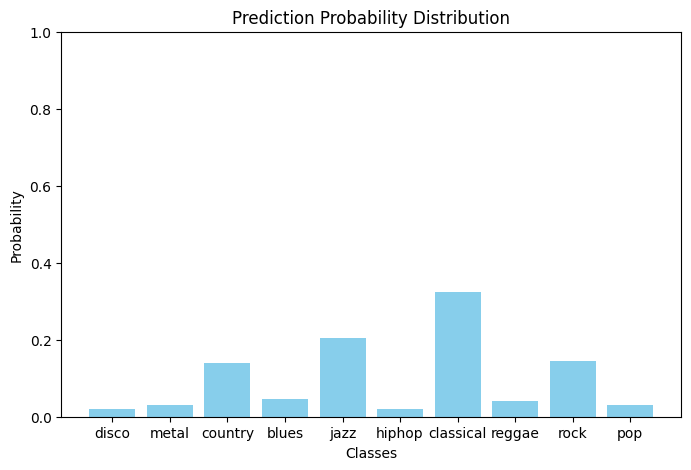

In [29]:
proba = rf_model.predict_proba(sample)[0]
class_labels = genres

# Plotting
plt.figure(figsize=(8, 5))
plt.ylim(0, 1)
plt.bar(class_labels, proba, color='skyblue')
plt.xlabel('Classes')
plt.ylabel('Probability')
plt.title('Prediction Probability Distribution')
plt.show()